Dost, 'kaggle.json' upload karein:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:00<00:00, 155MB/s]

Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Professional Training...
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 98ms/step - accuracy: 0.7033 - loss: 0.5731 - precision: 0.7008 - recall: 0.7095 - val_accuracy: 0.7421 - val_loss: 0.5250 - val_precision: 0.7444 - val_recall: 0.7374
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.7373 - loss: 0.5319 - precision: 0.7355 - recall: 0.7412 - val_accuracy: 0.7566 - val_loss: 0.5024 - val_precision: 0.7542 - val_recall: 0.7615
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 113s 90ms/step - accuracy: 0.7497 - loss: 0.5159 - precision: 0.7487 - recall: 0.7516 - val_accuracy: 0.7670 - val_loss: 0.4874 - val_precision: 0.7656 - val_recall: 

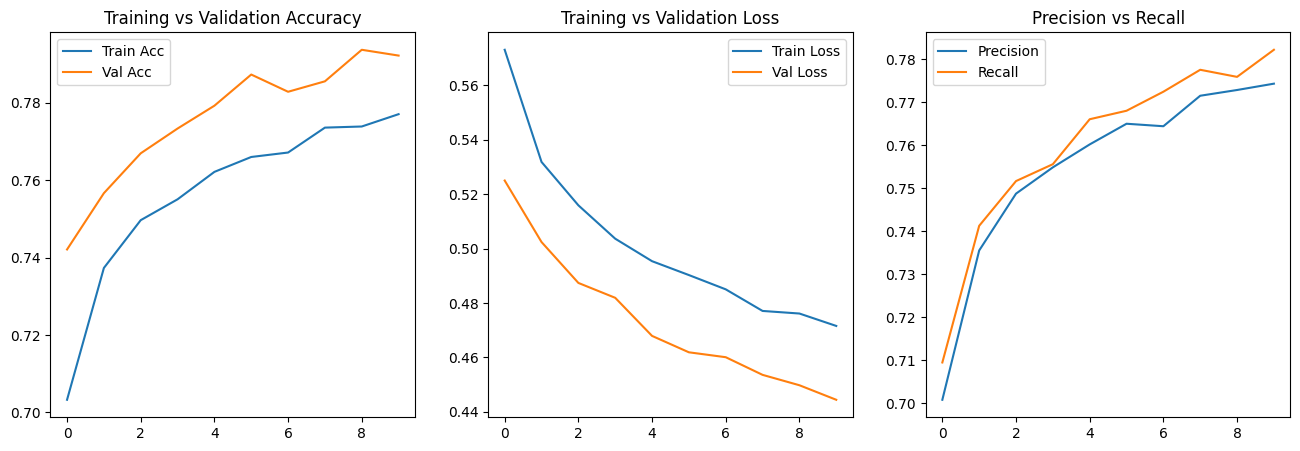


--- Generating Confusion Matrix ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step


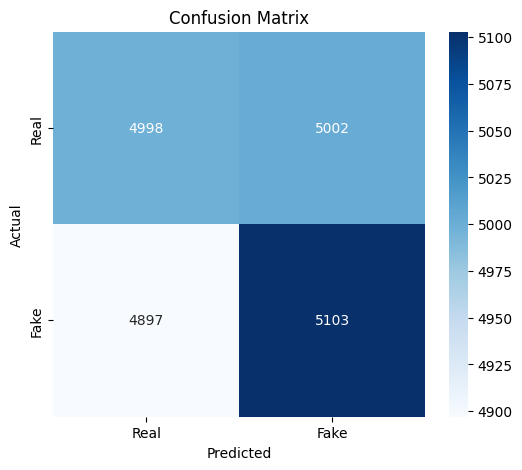


Classification Report:
               precision    recall  f1-score   support

        Real       0.51      0.50      0.50     10000
        Fake       0.50      0.51      0.51     10000

    accuracy                           0.51     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.51      0.51      0.51     20000



In [1]:
# ==========================================
# 1. ADVANCED LIBRARIES & DATASET SETUP
# ==========================================
import os, matplotlib.pyplot as plt, numpy as np, seaborn as sns
from google.colab import files
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

# Kaggle API Setup
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Dost, 'kaggle.json' upload karein:")
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Dataset Download & Extraction
if not os.path.exists('train'):
    !kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
    !unzip -q cifake-real-and-ai-generated-synthetic-images.zip

# ==========================================
# 2. DATA PIPELINE (Module 6: Augmentation)
# ==========================================
# 6th Sem Level: Using high-quality augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=15, horizontal_flip=True, brightness_range=[0.8, 1.2]
)

train_ds = datagen.flow_from_directory('train', target_size=(32, 32), batch_size=64, class_mode='binary', subset='training')
val_ds = datagen.flow_from_directory('train', target_size=(32, 32), batch_size=64, class_mode='binary', subset='validation')

# ==========================================
# 3. TRANSFER LEARNING ARCHITECTURE (Module 7 & 13)
# ==========================================
# Using ResNet50 for Deep Feature Extraction
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Module 4: Regularization
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=optimizers.Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# ==========================================
# 4. TRAINING WITH CALLBACKS (Module 3-4)
# ==========================================
# 6th Sem Level: EarlyStopping (to prevent overfitting)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

print("Starting Professional Training...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])

# ==========================================
# 5. ADVANCED VISUALIZATION & GRAPHS
# ==========================================
# A. Accuracy & Loss Curves
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# B. Precision-Recall Curve (Advanced Module 4 Topic)
plt.subplot(1, 3, 3)
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['recall'], label='Recall')
plt.title('Precision vs Recall')
plt.legend()
plt.show()

# C. Confusion Matrix (Module 8: Evaluation Metrics)
print("\n--- Generating Confusion Matrix ---")
val_ds.reset()
Y_pred = model.predict(val_ds)
y_pred = (Y_pred > 0.5).astype(int)
cm = confusion_matrix(val_ds.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# D. Classification Report
print("\nClassification Report:\n", classification_report(val_ds.classes, y_pred, target_names=['Real', 'Fake']))